In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("data/parsed_save2.csv")

In [4]:
data.head()

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.5,1,0,0,0,0.0,0.000,0.000,0.000,0.000,0.2,0.2,0,0.167,0.667,0,1.333,0.175
1,1,0.357,0.5,0,1,0,0,0.5,0.286,0.429,0.000,0.000,0.4,0.8,0,0.167,0.000,0,0.571,0.175
2,2,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.000,0,0.000,0.175
3,3,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.400,0,0.400,0.175
4,4,0.357,0.5,0,0,0,1,0.5,0.286,0.429,0.929,0.786,0.4,0.8,0,0.167,0.000,0,0.514,0.175


In [24]:
data.columns

Index(['Unnamed: 0', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop',
       'stage_turn', 'stage_river', 'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'if_fold', 'hero_bet_ratio', 'result'],
      dtype='str')

In [25]:
temp = data[data["stage_pre"] == 1]
temp.loc[temp["facing_ratio"] <= temp["hero_bet_ratio"]]

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.167,0.667,0,1.333,0.175
9,9,0.429,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.500,0.667,0,0.667,-0.020
12,12,0.571,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.833,0.833,0,0.833,0.085
14,14,0.357,0.571,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.000,0.667,0,1.333,-0.020
18,18,0.714,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.500,0.667,0,1.333,0.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,1252,0.786,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.000,0.667,0,1.333,0.275
1262,1262,1.000,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.667,0.667,0,0.667,-0.020
1264,1264,1.000,0.786,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.833,0.667,0,1.333,0.045
1275,1275,0.857,0.714,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.833,0.667,0,1.333,-0.190


In [26]:
temp.loc[temp["if_fold"] == 1, "action"] = "fold"
temp.loc[(temp["if_fold"] == 0) & (temp["hero_bet_ratio"] == 0), "action"] = "check"
temp.loc[(temp["facing_ratio"] < temp["hero_bet_ratio"]) & (temp["action"] != 0) & (temp["action"] != 1), "action"] = "raise"
temp.fillna({"action": "call"}, inplace=True)
temp["action"].value_counts()

action
fold     355
raise    176
call     159
check     17
Name: count, dtype: int64

In [27]:
temp.drop(columns=["Unnamed: 0","if_fold", "result"], inplace=True)


In [28]:
temp.columns

Index(['hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [29]:
from zlib import crc32
import numpy as np

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id: is_id_in_test_set(id, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [30]:
temp_with_id = temp.reset_index()
temp_with_id.columns
train_set, test_set = split_data_with_id_hash(temp_with_id, test_ratio=0.2, id_column="index")

In [31]:
train_set.columns

Index(['index', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [32]:
def x_y_separator(df, y = "action"):
    label = df[y]
    df.drop(columns=[y], inplace=True)
    return df, label

train_set, label = x_y_separator(train_set, "action")

In [33]:
def position_mapping(df, y = "position_norm"):
    POSITION_MAP = {
        0.000: "BTN",
        0.167: "SB",
        0.333: "BB",
        0.500: "UTG",
        0.667: "HJ",
        0.833: "CO",
    }

    temp = df[y].round(3).map(POSITION_MAP)
    df[y] = temp
    return df

train_set = position_mapping(train_set)


In [34]:
train_set.columns

Index(['index', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio'],
      dtype='str')

In [35]:
train_set.drop(columns=['index', 'stage_flop',
       'stage_turn', 'stage_river',
       'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'hero_bet_ratio'], inplace=True)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

x_train = train_set
y_train = label

categorical_cols = ["position_norm"]
numeric_cols = [
    "hero_r1",
    "hero_r2",
    "stage_pre",
    "suit_po",
    "stra_po",
    "gut_po",
    "facing_ratio"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("position", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("numerical", StandardScaler(), numeric_cols),
    ],
    remainder="passthrough",

).set_output(transform="pandas")

x_train_prepared = preprocessor.fit_transform(x_train)
print(x_train_prepared.columns)

Index(['position__position_norm_BB', 'position__position_norm_BTN',
       'position__position_norm_CO', 'position__position_norm_HJ',
       'position__position_norm_SB', 'position__position_norm_UTG',
       'numerical__hero_r1', 'numerical__hero_r2', 'numerical__stage_pre',
       'numerical__suit_po', 'numerical__stra_po', 'numerical__gut_po',
       'numerical__facing_ratio'],
      dtype='str')


In [37]:
from sklearn.dummy import DummyClassifier

DummyClassifier(strategy="most_frequent")

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ('model', LogisticRegression(l1_ratio=0)),
    ])

param_grid = { "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
               "model__class_weight": [None, "balanced"]}

ss = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)

search = GridSearchCV(pipeline, param_grid=param_grid, scoring="f1_macro", cv=ss, n_jobs=-1, return_train_score=True)

model = search.fit(x_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__C': 1, 'model__class_weight': None}
0.534112771648569


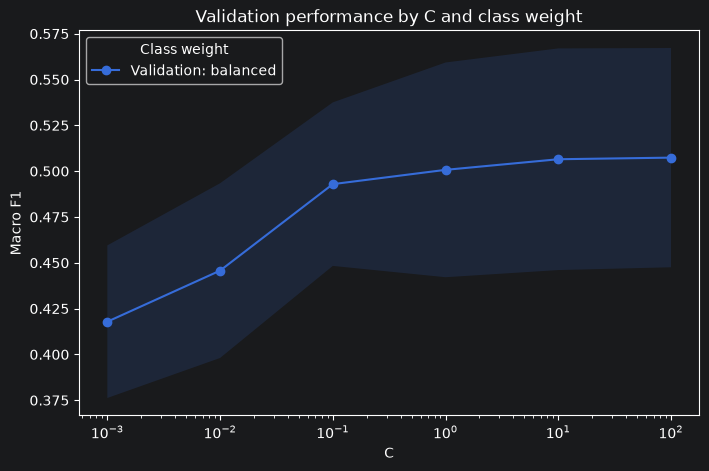

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)
results.to_csv('result.csv')

fig, ax = plt.subplots(figsize=(8, 5))

for class_weight, group in results.groupby("param_model__class_weight"):
    group = group.sort_values("param_model__C")

    c_values = group["param_model__C"].astype(float)
    validation_mean = group["mean_test_score"]
    validation_std = group["std_test_score"]

    label = "None" if class_weight is None else str(class_weight)

    ax.semilogx(
        c_values,
        validation_mean,
        marker="o",
        label=f"Validation: {label}"
    )

    ax.fill_between(
        c_values,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )

ax.set_xlabel("C")
ax.set_ylabel("Macro F1")
ax.set_title("Validation performance by C and class weight")
ax.legend(title="Class weight")
plt.show()

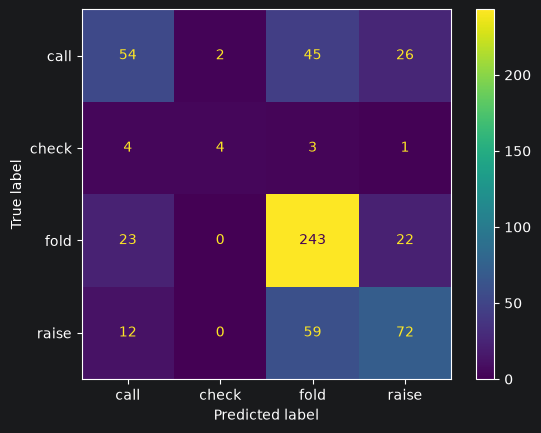

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prediction = model.predict(x_train)


ConfusionMatrixDisplay.from_predictions(
    label,
    prediction,
    labels=model.classes_,
    normalize=None,
)

plt.show()


In [40]:
test_x, test_label = x_y_separator(test_set, "action")
test_x = position_mapping(test_set)
test_x.drop(columns=['index', 'stage_flop',
       'stage_turn', 'stage_river',
       'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'hero_bet_ratio'], inplace=True)
predicted_y = model.predict(test_x)
confusion_matrix(test_label, predicted_y)

array([[13,  0, 14,  5],
       [ 2,  2,  1,  0],
       [ 5,  0, 59,  3],
       [ 2,  0, 17, 14]])

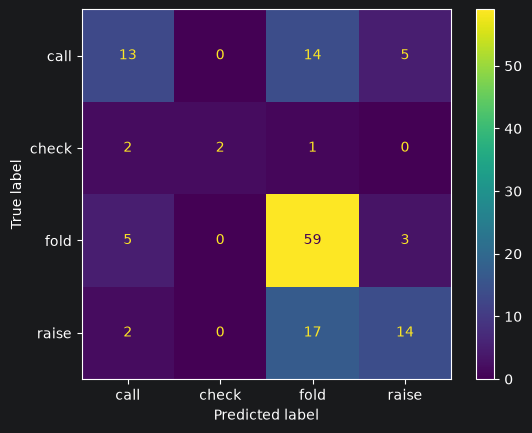

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    test_label,
    predicted_y,
    labels=model.classes_,
    normalize=None,
)

plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(
    test_label,
    predicted_y,
)
)

              precision    recall  f1-score   support

        call       0.59      0.41      0.48        32
       check       1.00      0.40      0.57         5
        fold       0.65      0.88      0.75        67
       raise       0.64      0.42      0.51        33

    accuracy                           0.64       137
   macro avg       0.72      0.53      0.58       137
weighted avg       0.64      0.64      0.62       137

